# Project Setup — Employee Attrition Prediction (Classification)

## This project focuses on predicting whether an employee will leave a company using both Machine Learning and Deep Learning approaches, then comparing their performance.

## 0. Libraries for Data Processing, Modeling, and Evaluation

This section imports all libraries required across the full pipeline:

### Categories:
- Data Processing & Visualization
- Preprocessing & Splitting
- Machine Learning Models
- Evaluation Metrics
- Model Optimization
- Deep Learning (ANN)
- My src files

These tools support both:
- Traditional Machine Learning models
- Deep Learning model (ANN)

This unified setup ensures consistency across experiments and comparisons.

In [1]:
# 1: Basic Data Processing & Visualization (Your Part)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2: Preprocessing & Splitting (The bridge between you and them)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# 3: Model Building (For the next student)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 4: Model Evaluation Metrics (For the evaluation part)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay
)

# 5: Model Optimization (For the final part)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# 6: Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# 7: src files
import sys
import os
# Add project root directory to Python path
sys.path.append(os.path.abspath(".."))
from src.data_cleaning import clean_data
from src.preprocessing import ordinal_encode, split_data, encode_and_scale
from src.model import build_models, train_models
from src.model import build_ann, predict_ann
from src.model import get_feature_importance, select_top_features, tune_random_forest
from src.evaluation import evaluate_model, print_evaluation, plot_conf_matrix

# Ignore warnings to keep the notebook clean
import warnings
warnings.filterwarnings('ignore')

print("All libraries for all stages are loaded successfully!")

All libraries for all stages are loaded successfully!


# 1. Read Dataset

In this step, we load the dataset and perform an initial inspection.

### Objectives:
- Understand dataset size (rows, columns)
- Check data types
- Identify missing values
- View statistical summary
- Preview sample records

This step helps guide preprocessing and modeling decisions.

In [2]:
# Load dataset
df = pd.read_csv("../data/dataset.csv")  # adjust path if needed

print("Dataset Overview:")
print("Shape:", df.shape)

print("\nInfo:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nFirst 5 rows:")
df.head()

Dataset Overview:
Shape: (14999, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Departments            14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Statistical Summary:
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean           

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 2. Data Cleaning

This step prepares the dataset for modeling.

### Key operations:
- Standardize column names
- Handle missing values
- Remove duplicate records
- Fix incorrect data types

Clean data improves model performance and stability.

In [3]:
# Apply cleaning
df = clean_data(df)

# Preview cleaned data
df.head()

Missing values before cleaning:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Departments              0
salary                   0
dtype: int64

Removing 3008 duplicate rows...

Data Cleaning Completed.

Missing values after cleaning:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Departments              0
salary                   0
dtype: int64


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 3. Exploratory Data Analysis (EDA)

In this section, we explore the dataset to:
- Understand feature distributions
- Identify patterns related to employee attrition
- Detect potential relationships between variables

EDA helps guide feature selection and model design.

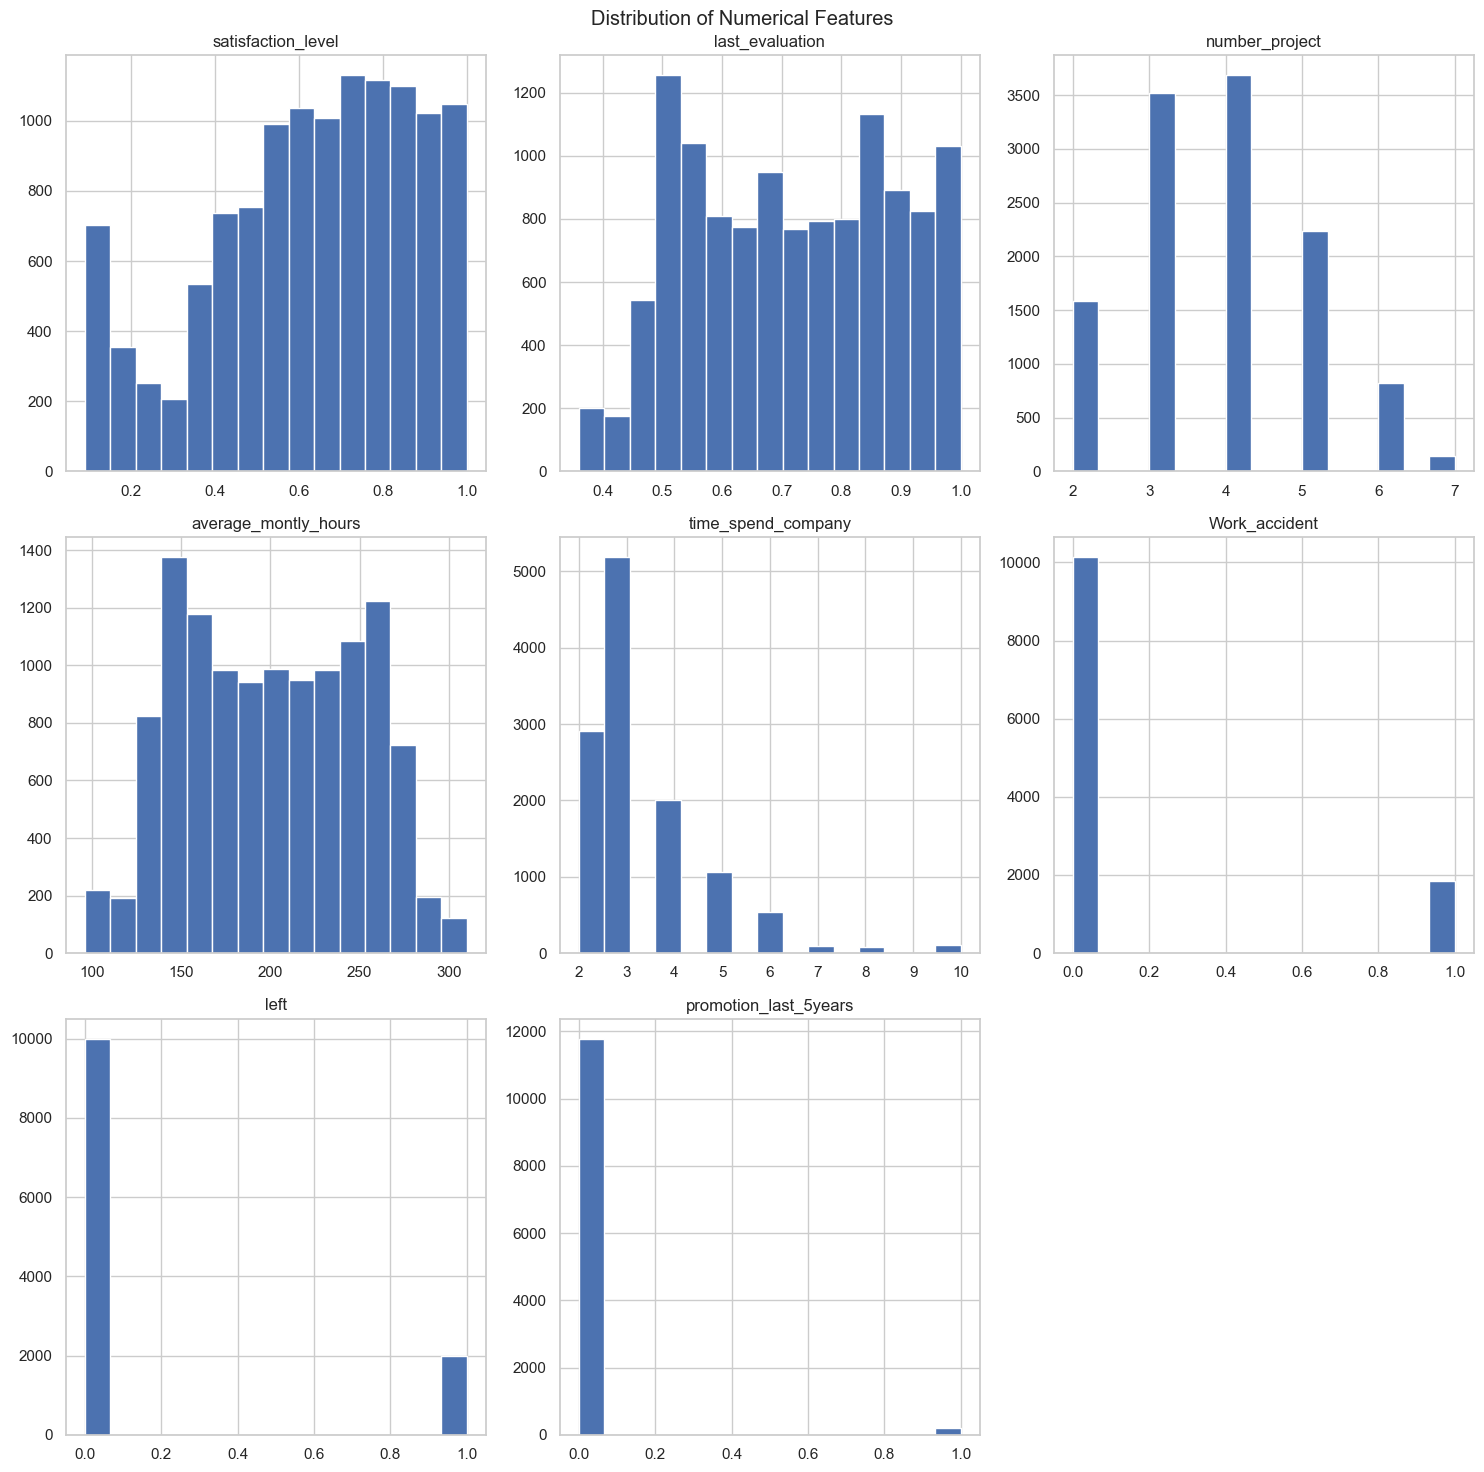

In [4]:
sns.set_theme(style="whitegrid")

# 1. Numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Dynamic layout
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

df[numerical_cols].hist(bins=15, figsize=(15, 5 * n_rows), layout=(n_rows, n_cols))

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

### Correlation Analysis
We analyze the linear relationship between numerical features and the target variable.
*Note: Due to merging multiple databases, initial correlation might appear low, requiring further deep-dive into categorical features.*

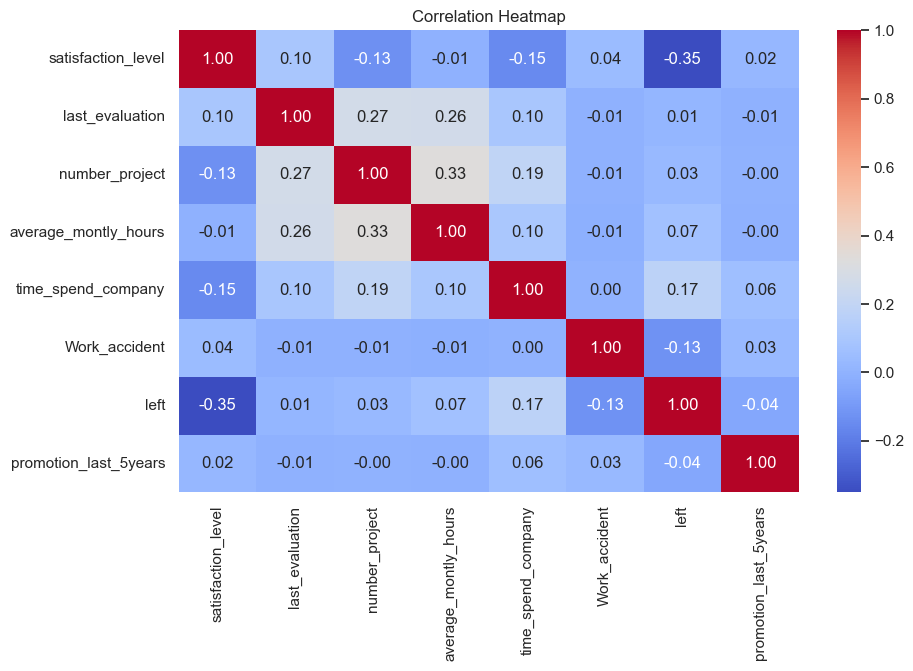

In [5]:
plt.figure(figsize=(10, 6))

correlation_matrix = df.corr(numeric_only=True)


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### Attrition Rate by Departments
Since Job Role is a key categorical feature, we calculate the percentage of employees leaving within each role to identify high-risk departments.

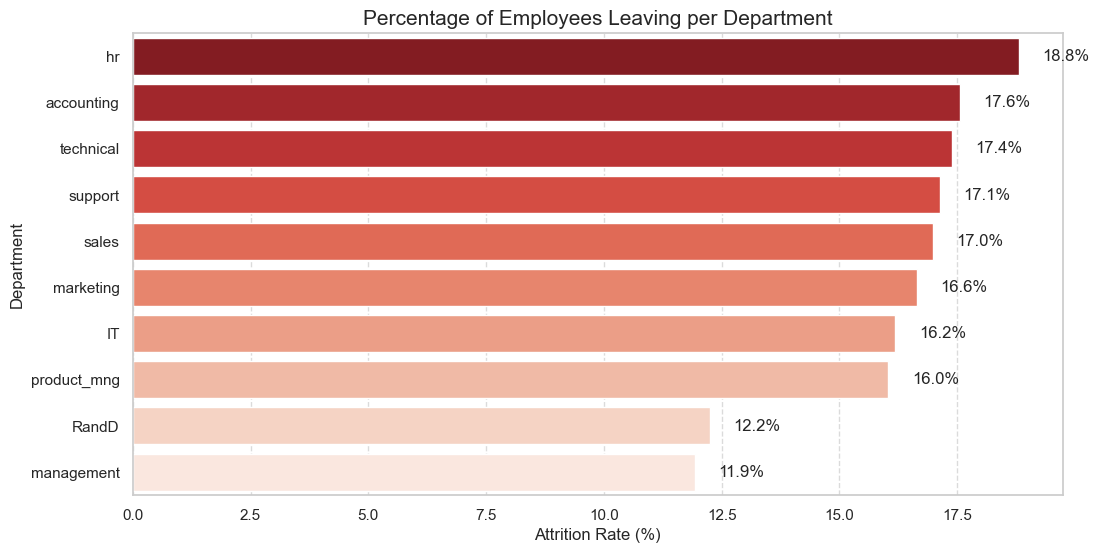

In [6]:
# Group by Departments
attrition_rate = (
    df.groupby('Departments')['left']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=attrition_rate.values,
    y=attrition_rate.index,
    palette='Reds_r'
)

plt.title('Percentage of Employees Leaving per Department', fontsize=15)
plt.xlabel('Attrition Rate (%)', fontsize=12)
plt.ylabel('Department', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add percentage labels
for i, v in enumerate(attrition_rate.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.show()

## 4. Data Preprocessing

We perform:
- Ordinal encoding (salary)
- Train-test split
- One-hot encoding (categorical features)
- Feature scaling (numeric features)

In [7]:
# 1. Ordinal encoding
df = ordinal_encode(df)

# 2. Split
X_train, X_test, y_train, y_test = split_data(df)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 3. Encode + Scale
X_train, X_test, encoder, scaler = encode_and_scale(X_train, X_test)

X_train.head()

Train shape: (9592, 9)
Test shape: (2399, 9)
Categorical: ['Departments']
Numeric: ['average_montly_hours', 'time_spend_company', 'number_project']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,Departments_IT,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical
2032,0.98,0.91,0.0,0.465116,0.0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10435,0.63,0.89,-0.5,0.453488,0.0,0,0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.85,0.59,-0.5,0.406977,0.0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
11597,0.56,0.39,-0.5,-1.093023,5.0,0,0,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1999,0.50,0.75,1.0,-0.848837,0.0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Model Building (Machine Learning)

We train three models:
- Logistic Regression (baseline, interpretable)
- Random Forest (ensemble, handles non-linearity)
- XGBoost (boosting, strong performance)

We also handle class imbalance to improve prediction of minority class (attrition).

In [8]:
# Build models
log_model, rf_model, xgb_model = build_models(y_train)

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Train
trained_models = train_models(models, X_train, y_train)

## 6. Model Evaluation

We evaluate models using multiple metrics:

- Accuracy → overall correctness
- Precision → how many predicted positives are correct
- Recall → how many actual positives are captured
- F1 Score → balance between precision and recall
- ROC-AUC → model's ranking ability
- Log Loss → probability calibration

We also visualize performance using confusion matrices.


===== Logistic Regression (threshold=0.5) =====
Confusion Matrix:
[[1539  462]
 [  62  336]]
Accuracy:  0.7816
Precision: 0.4211
Recall:    0.8442
F1 Score:  0.5619
ROC-AUC:   0.8502
Log Loss:  0.5300


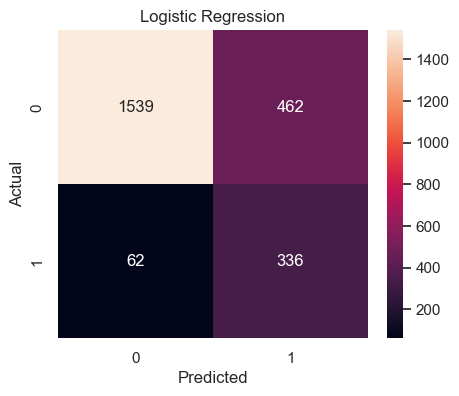


===== Random Forest (threshold=0.5) =====
Confusion Matrix:
[[1994    7]
 [  31  367]]
Accuracy:  0.9842
Precision: 0.9813
Recall:    0.9221
F1 Score:  0.9508
ROC-AUC:   0.9808
Log Loss:  0.0960


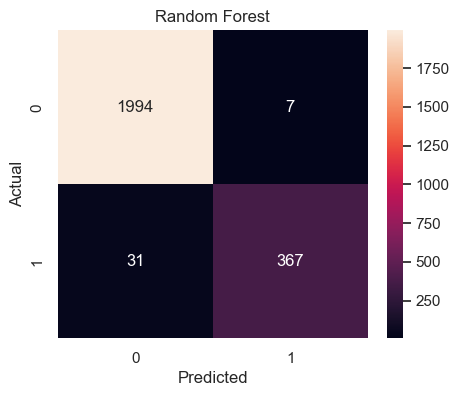


===== XGBoost (threshold=0.5) =====
Confusion Matrix:
[[1971   30]
 [  26  372]]
Accuracy:  0.9767
Precision: 0.9254
Recall:    0.9347
F1 Score:  0.9300
ROC-AUC:   0.9833
Log Loss:  0.0835


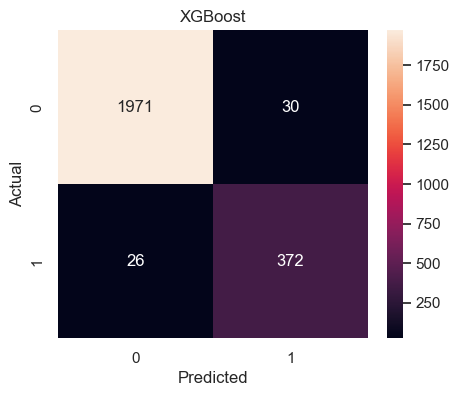

,accuracy,precision,recall,f1_score,roc_auc,log_loss
Logistic Regression,0.781576,0.421053,0.844221,0.561873,0.850183,0.529999
Random Forest,0.98416,0.981283,0.922111,0.950777,0.98079,0.095999
XGBoost,0.976657,0.925373,0.934673,0.93,0.98326,0.083495


In [9]:
results = {}

for name, model in trained_models.items():
    res = evaluate_model(model, X_test, y_test)
    results[name] = res

    print_evaluation(res, name, threshold=0.5)
    plot_conf_matrix(res, name)

# Comparison Table
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.drop(columns=["confusion_matrix"])

comparison_df

## 7. Model ANN (Deep Learning)

We build an Artificial Neural Network (ANN) to compare with traditional ML models.

- Handles complex feature interactions
- Requires more data and tuning
- Less interpretable than ML models

In [10]:
# Train ANN
ann_model, history = build_ann(
    X_train, y_train,
    X_val=X_test, y_val=y_test
)

# Predict
y_pred, y_prob = predict_ann(ann_model, X_test)

Epoch 1/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8777 - loss: 0.2957 - val_accuracy: 0.9450 - val_loss: 0.1743
Epoch 2/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9444 - loss: 0.1698 - val_accuracy: 0.9591 - val_loss: 0.1484
Epoch 3/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9528 - loss: 0.1539 - val_accuracy: 0.9579 - val_loss: 0.1408
Epoch 4/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9563 - loss: 0.1456 - val_accuracy: 0.9637 - val_loss: 0.1337
Epoch 5/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9586 - loss: 0.1394 - val_accuracy: 0.9650 - val_loss: 0.1293
Epoch 6/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9600 - loss: 0.1333 - val_accuracy: 0.9587 - val_loss: 0.1357
Epoch 7/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9614 - loss: 0.1294 - val_accuracy: 0.9654 - val_loss: 0.1234
Epoch 8/32
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9621 - loss: 0.1244 - val_accuracy: 0.

## 8. Evaluate ANN Model

We evaluate the Artificial Neural Network (ANN) using the same metrics as ML models:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Log Loss

This ensures a fair comparison between ML and Deep Learning approaches.


===== ANN Model =====
Confusion Matrix:
[[1964   37]
 [  41  357]]
Accuracy   : 0.9674864526886202
Precision  : 0.9060913705583756
Recall     : 0.8969849246231156
F1 Score   : 0.9015151515151515
ROC-AUC    : 0.977859060419539
Log Loss   : 0.10839085548335037


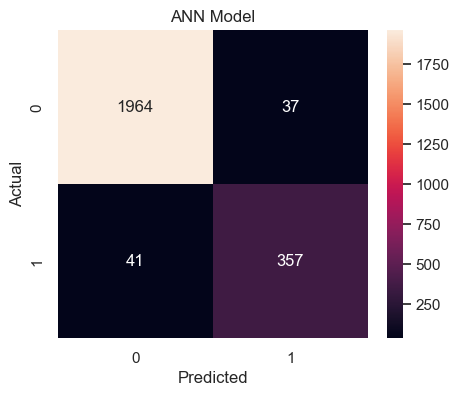

In [11]:
print("\n===== ANN Model =====")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy   :", accuracy_score(y_test, y_pred))
print("Precision  :", precision_score(y_test, y_pred))
print("Recall     :", recall_score(y_test, y_pred))
print("F1 Score   :", f1_score(y_test, y_pred))
print("ROC-AUC    :", roc_auc_score(y_test, y_prob))
print("Log Loss   :", log_loss(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("ANN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9a. Feature Selection using Random Forest Importance

We use feature importance from Random Forest to:
- Identify most influential features
- Reduce dimensionality
- Improve model efficiency

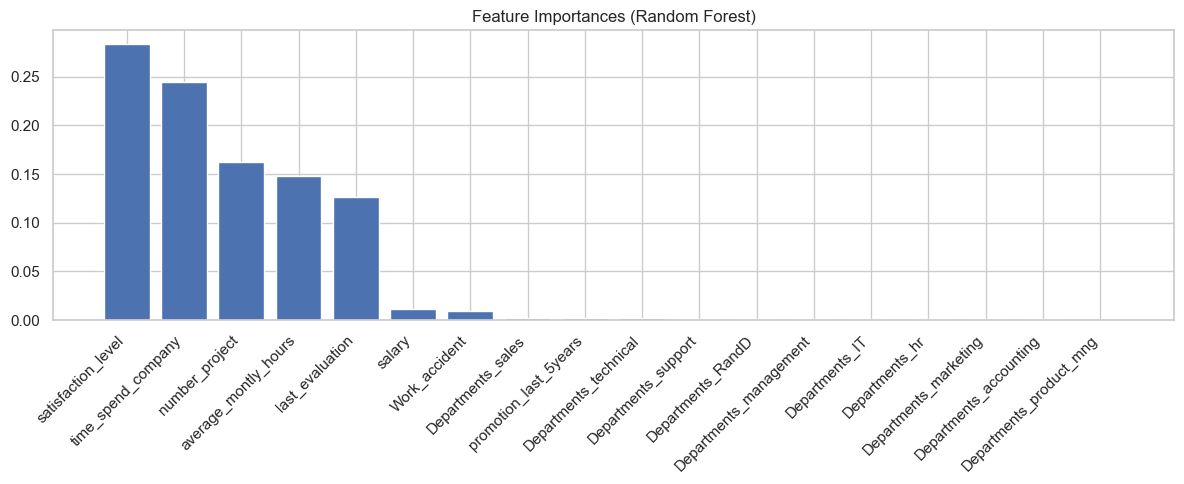

Selected features: ['satisfaction_level', 'time_spend_company', 'number_project', 'average_montly_hours', 'last_evaluation', 'salary']


In [12]:
feature_names = X_train.columns

importances, indices = get_feature_importance(rf_model, feature_names)

# Plot
plt.figure(figsize=(12, 5))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(feature_names)), importances[indices])
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Select top features
selected_features = select_top_features(importances, indices, feature_names)

print("Selected features:", selected_features)

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

## 9b. Hyperparameter Tuning (Random Forest)

We use RandomizedSearchCV to:
- Explore a wide parameter space efficiently
- Optimize for F1 score (important for imbalanced data)## 9b. Hyperparameter Tuning (Random Forest)

We use RandomizedSearchCV to:
- Explore a wide parameter space efficiently
- Optimize for F1 score (important for imbalanced data)

In [13]:
rf_random = tune_random_forest(X_train_sel, y_train)

print("Best params:", rf_random.best_params_)
print("Best F1 (CV):", rf_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best F1 (CV): 0.9481332066919634


## 10. Final Model Comparison

We compare all models using:
- F1 Score (primary metric)
- ROC-AUC (overall performance)

In [14]:
results = {}

models = {
    "Logistic Regression": log_model,
    "Random Forest (tuned)": rf_random.best_estimator_,
    "XGBoost": xgb_model,
    "ANN": ann_model
}

for name, m in models.items():

    X_eval = X_test_sel if name == "Random Forest (tuned)" else X_test

    if name == "ANN":
        y_prob = m.predict(X_eval).flatten()
    else:
        y_prob = m.predict_proba(X_eval)[:, 1]

    y_pred = (y_prob > 0.5).astype(int)

    results[name] = {
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    }

results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
results_df

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step


,F1,ROC-AUC
Random Forest (tuned),0.9547,0.9793
XGBoost,0.9300,0.9833
ANN,0.9015,0.9779
Logistic Regression,0.5619,0.8502


## 11. Final Model Selection & Justification

The best model is selected based on:
- Highest F1 Score
- Strong ROC-AUC
- Interpretability

              precision    recall  f1-score   support

      Stayed       0.99      1.00      0.99      2001
        Left       0.98      0.93      0.95       398

    accuracy                           0.99      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399

F1 Score : 0.9547218628719275
ROC-AUC  : 0.979294900288549


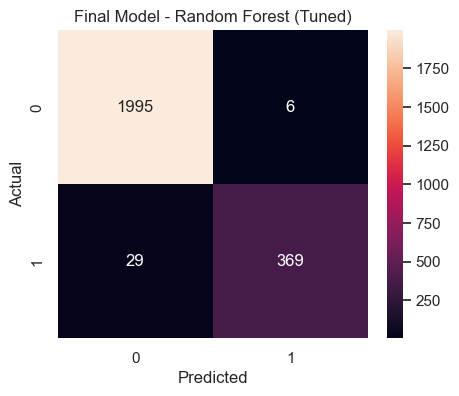

In [15]:
best_model = rf_random.best_estimator_

y_prob_final = best_model.predict_proba(X_test_sel)[:, 1]
y_pred_final = (y_prob_final > 0.5).astype(int)

print(classification_report(y_test, y_pred_final,
      target_names=["Stayed", "Left"]))

print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Final Model - Random Forest (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()